In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ANCHOR = "KC=F"
EQUITIES = ["SBUX", "BROS", "KDP", "SJM", "NSRGY", "JDEP", "MDLZ", "FARM", "TAST", "WEST"]
PROXIES = ["DBA"]

ALL_TICKERS = [ANCHOR] + PROXIES + EQUITIES

In [13]:
import os

CSV_PATH = "coffee_dataset_G17.csv"

if os.path.exists(CSV_PATH):
    print(f"CSV déjà existant ({CSV_PATH}), aucun écrasement.")
    df_close = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
else:
    print(f"Téléchargement des données pour {len(ALL_TICKERS)} actifs...")
    raw_data = yf.download(ALL_TICKERS, start="2020-01-01", end="2026-03-29")
    df_close = raw_data['Close'].dropna(thresh=len(ALL_TICKERS)*0.8)
    df_close.to_csv(CSV_PATH)
    print(f"Dataset sauvegardé : {CSV_PATH}")

print(f"Dimensions : {df_close.shape}")
print(f"Période : {df_close.index[0].date()} -> {df_close.index[-1].date()}")

CSV déjà existant (coffee_dataset_G17.csv), aucun écrasement.
Dimensions : (1093, 12)
Période : 2021-10-20 -> 2026-02-27


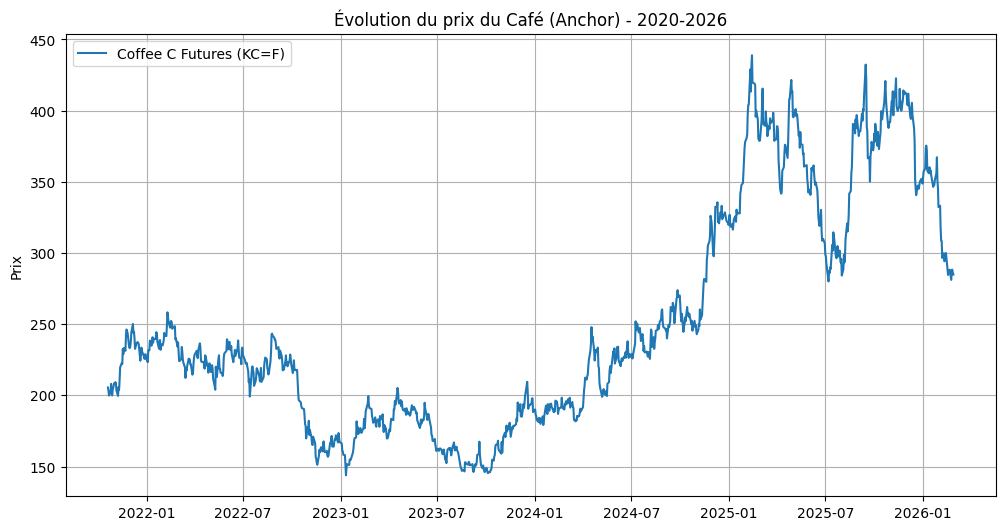

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(df_close[ANCHOR], label="Coffee C Futures (KC=F)")
plt.title("Évolution du prix du Café (Anchor) - 2020-2026")
plt.ylabel("Prix")
plt.legend()
plt.grid(True)
plt.show()